In [1]:
import pandas as pd

import matplotlib.pyplot as plt

In [33]:
df = pd.read_excel('Euro.xlsx')

df['Tarih'] = pd.to_datetime(df['Tarih'], dayfirst=True)
df = df.set_index('Tarih')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1827 entries, 2019-04-20 to 2024-04-19
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Dolar   1253 non-null   float64
dtypes: float64(1)
memory usage: 28.5 KB


In [4]:
# Indexing and filling null values with interpolation for resample data values
df['Dolar'].interpolate(method='linear', inplace=True)
df["Dolar"] = df["Dolar"].astype("float32")

In [5]:
df.dropna(inplace=True)

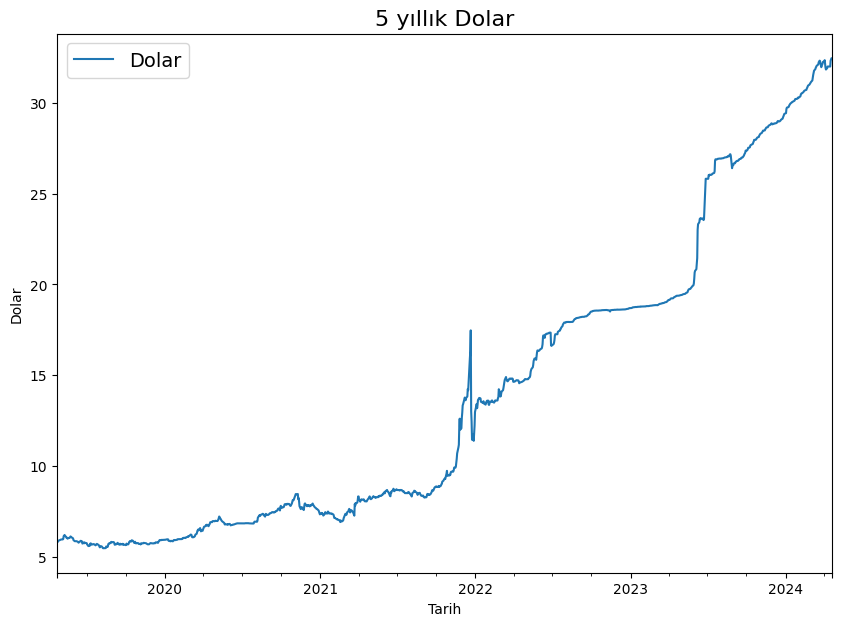

In [6]:
df.plot(figsize=(10,7))
plt.ylabel("Dolar")
plt.title("5 yıllık Dolar", fontsize=16)
plt.legend(fontsize=14)

In [7]:
## Format data part 1: Create train and test sets of our time series data 

# Creating train and test sets with time series data (the wrong way)

# Get bitcoin data array

timesteps = df.index.to_numpy()
prices    = df["Dolar"].to_numpy()

timesteps[:10], prices[:10]

(array(['2019-04-22T00:00:00.000000000', '2019-04-23T00:00:00.000000000',
        '2019-04-24T00:00:00.000000000', '2019-04-25T00:00:00.000000000',
        '2019-04-26T00:00:00.000000000', '2019-04-27T00:00:00.000000000',
        '2019-04-28T00:00:00.000000000', '2019-04-29T00:00:00.000000000',
        '2019-04-30T00:00:00.000000000', '2019-05-01T00:00:00.000000000'],
       dtype='datetime64[ns]'),
 array([5.7921 , 5.8087 , 5.8253 , 5.8598 , 5.8927 , 5.9029 , 5.9131 ,
        5.9233 , 5.9282 , 5.94225], dtype=float32))

In [8]:
### Create train & test sets for time series (the right way)

# Create train and test splits the right way for time series data

split_size = int(0.8 * len(prices)) # 80% train, 20% test 

# Create train data splits (everything before the split)

X_train, y_train = timesteps[:split_size], prices[:split_size]

# Create test data splits (everything beyond the split)

X_test, y_test = timesteps[split_size:], prices[split_size:]

len(X_train), len(X_test), len(y_train), len(y_test)

(1460, 365, 1460, 365)

In [9]:
# Creating a plotting function

# Typing plotting code is tedious, let's functionize it. 

# Create a function to plot time series data

def plot_time_series(timesteps, values, format=".",start=0,end=None, label=None):
    plt.plot(timesteps[start:end], values[start:end], format, label=label)
    plt.xlabel("Tarih")
    plt.ylabel("Dolar")

    if label:
        
        plt.legend(fontsize=14)
    plt.grid(True)

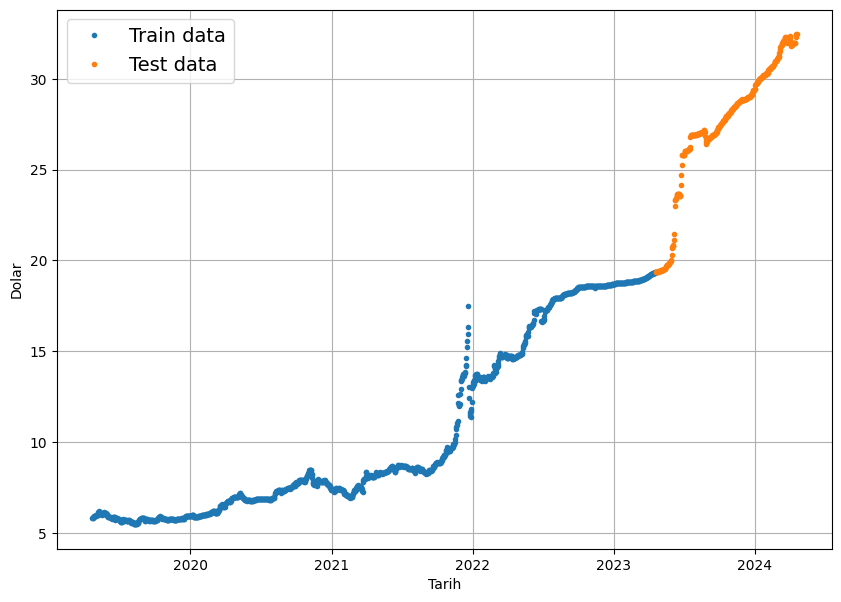

In [10]:
# Test out plottin function

plt.figure(figsize=(10,7))
plot_time_series(timesteps=X_train, values=y_train, label="Train data")
plot_time_series(timesteps=X_test, values=y_test, label="Test data")

In [11]:
import tensorflow as tf

# MASE implementation 

def mean_absolute_scaled_error(y_true, y_pred):
    """
    Implement MASE (assuming no seasonality of data).

    """

    mae = tf.reduce_mean(tf.abs(y_true-y_pred))

    # Find MAE of naive forecast (no seasonality)

    mae_naive_no_season = tf.reduce_mean(tf.abs(y_true[1:] - y_true[:-1])) # our seasonality is 1 day (hence the shift of 1)

    return mae / mae_naive_no_season


In [12]:
def evaluate_preds(y_true, y_pred):
    
    # Make sure float32 datatype (for metric calculations)

    y_true = tf.cast(y_true, dtype=tf.float32)
    y_pred = tf.cast(y_pred, dtype=tf.float32)

    # Calculate various evaluation metrics

    mae  = tf.keras.metrics.mean_absolute_error(y_true, y_pred)
    mse  = tf.keras.metrics.mean_squared_error(y_true, y_pred)
    rmse = tf.sqrt(mse)
    mape = tf.keras.metrics.mean_absolute_percentage_error(y_true, y_pred)
    mase = mean_absolute_scaled_error(y_true, y_pred)

    return {
        "mae" : mae.numpy(),
        "mse" : mse.numpy(),
        "rmse": rmse.numpy(),
        "mape": mape.numpy(),
        "mase": mase.numpy()
        }


In [13]:
# Let's setup global variables for window and horizon size

HORIZON = 1     # predict next 1 day
WINDOW_SIZE = 7 # use the past week of Dolar data to make the prediction

In [14]:
# Create function to label windowed data

def get_labelled_windows(x, horizon=HORIZON):
    """  
    Creates labels for windowed dataset.

    E.g. if horizon = 1
    Input: [0, 1, 2, 3, 4, 5, 6, 7] -> Output: ([0, 1, 2, 3, 4, 5, 6], [7])
    """

    return x[:, :-horizon], x[:, -horizon:]

In [15]:
# Test out the window labelling function

test_window, test_label = get_labelled_windows(tf.expand_dims(tf.range(8), axis=0))
print(f"Window: {tf.squeeze(test_window).numpy()} -> Label: {tf.squeeze(test_label).numpy()}")

Window: [0 1 2 3 4 5 6] -> Label: 7


In [16]:
import numpy as np

def make_windows(x, window_size=WINDOW_SIZE, horizon=HORIZON):
    """  
    Turns a 1D array into a 2D array of sequential labelled windows of window_size with horizon size labels.

    """

    # 1. Create a window of specifin window_size (add the horizon on the end for labelling later)

    window_step = np.expand_dims(np.arange(window_size+horizon), axis=0)

    # 2. Create a 2D array of multiple window steps (minus 1 to account for 0 indexing)

    window_indexes = window_step + np.expand_dims(np.arange(len(x)-(window_size+horizon-1)),axis=0).T # create 2D array of windows of size window_size
    # print(f"Window indexes:\n {window_indexes, window_indexes.shape}")

    # 3. Index on the target array (a time series) with 2D array of multiple window steps

    windowed_array = x[window_indexes]
    # print(windowed_array)

    # 4. Get the labelled windows

    windows, labels = get_labelled_windows(windowed_array, horizon=horizon)

    return windows, labels 


In [17]:
full_windows, full_labels = make_windows(prices, window_size=WINDOW_SIZE,horizon=HORIZON)
len(full_windows), len(full_labels)

(1818, 1818)

In [18]:
# View the first 3 windows/labels 

for i in range(3):
    print(f"Window: {full_windows[i]} -> Label {full_labels[i]}")

Window: [5.7921 5.8087 5.8253 5.8598 5.8927 5.9029 5.9131] -> Label [5.9233]
Window: [5.8087 5.8253 5.8598 5.8927 5.9029 5.9131 5.9233] -> Label [5.9282]
Window: [5.8253 5.8598 5.8927 5.9029 5.9131 5.9233 5.9282] -> Label [5.94225]


In [19]:
# View the last 3 windows/labels 

for i in range(3):
    print(f"Window: {full_windows[i-3]} -> Label {full_labels[i-3]}")

Window: [32.006  32.006  32.006  32.006  32.006  32.006  32.3271] -> Label [32.4049]
Window: [32.006  32.006  32.006  32.006  32.006  32.3271 32.4049] -> Label [32.4626]
Window: [32.006  32.006  32.006  32.006  32.3271 32.4049 32.4626] -> Label [32.4551]


In [20]:
# Turning windows into training and test sets

def make_train_test_splits(windows, labels, test_split=0.2):
    """  
    Splits matching pairs of windows and labels into train and test splits.
    """

    split_size = int(len(windows) * (1-test_split)) # this will default to 80% train / 20% test dataset
    train_windows = windows[:split_size]
    train_labels  = labels[:split_size]
    test_windows  = windows[split_size:]
    test_labels   = labels[split_size:] 

    return train_windows, test_windows, train_labels, test_labels

In [21]:
# Create train and test windows

train_windows, test_windows, train_labels, test_labels = make_train_test_splits(full_windows, full_labels, test_split=0.2)
len(train_windows), len(test_windows), len(train_labels), len(test_labels)

(1454, 364, 1454, 364)

In [22]:
train_windows[:5], train_labels[:5]

(array([[5.7921 , 5.8087 , 5.8253 , 5.8598 , 5.8927 , 5.9029 , 5.9131 ],
        [5.8087 , 5.8253 , 5.8598 , 5.8927 , 5.9029 , 5.9131 , 5.9233 ],
        [5.8253 , 5.8598 , 5.8927 , 5.9029 , 5.9131 , 5.9233 , 5.9282 ],
        [5.8598 , 5.8927 , 5.9029 , 5.9131 , 5.9233 , 5.9282 , 5.94225],
        [5.8927 , 5.9029 , 5.9131 , 5.9233 , 5.9282 , 5.94225, 5.9563 ]],
       dtype=float32),
 array([[5.9233 ],
        [5.9282 ],
        [5.94225],
        [5.9563 ],
        [5.9571 ]], dtype=float32))

In [23]:
test_windows[:5], test_labels[:5]

(array([[19.316767, 19.326534, 19.3363  , 19.3542  , 19.3755  , 19.3806  ,
         19.3806  ],
        [19.326534, 19.3363  , 19.3542  , 19.3755  , 19.3806  , 19.3806  ,
         19.3806  ],
        [19.3363  , 19.3542  , 19.3755  , 19.3806  , 19.3806  , 19.3806  ,
         19.3806  ],
        [19.3542  , 19.3755  , 19.3806  , 19.3806  , 19.3806  , 19.3806  ,
         19.3806  ],
        [19.3755  , 19.3806  , 19.3806  , 19.3806  , 19.3806  , 19.3806  ,
         19.3853  ]], dtype=float32),
 array([[19.3806],
        [19.3806],
        [19.3806],
        [19.3853],
        [19.3937]], dtype=float32))

In [24]:
import os 

# Create a function to impement a ModelCheckpoint callback with a specific filename

def create_model_checkpoint(model_name, save_path="model_experiments"):
    return tf.keras.callbacks.ModelCheckpoint(filepath=os.path.join(save_path,model_name),
                                                                    verbose=0,
                                                                    save_best_only=True)

In [25]:
def make_preds(model, input_data):
    """  
    Uses model to make predictions input_data.
    """
    forecast = model.predict(input_data)
    return tf.squeeze(forecast) # return 1D array of predictions

In [ ]:
## Model 2: Dense (window = 30, horizon = 1)

HORIZON = 1 # predict one step at a time (one day of Bitcoin prices)
WINDOW_SIZE = 30 # use 30 timesteps in past

In [ ]:
# Make windowed data with appropriate horizon and window sizes

full_windows, full_labels = make_windows(prices, window_size=WINDOW_SIZE, horizon=HORIZON)

len(full_windows), len(full_labels)

In [ ]:
# Make train and testing windows

train_windows, test_windows, train_labels, test_labels = make_train_test_splits(windows=full_windows,
                                                                                labels=full_labels,
                                                                                test_split=0.2)

len(train_windows), len(test_windows), len(train_labels), len(test_labels)

In [ ]:
train_windows[:3], train_labels[:3]

In [27]:
tf.random.set_seed(42)

model_2 = tf.keras.Sequential([ 
    tf.keras.layers.Dense(128,activation="relu"),
    tf.keras.layers.Dense(HORIZON,activation="linear")
],name="model_2_dense")

model_2.compile(
    loss = "mae",
    optimizer = tf.keras.optimizers.Adam(),
    metrics = ["mae","mse"]
)

history_model_2 = model_2.fit(
    train_windows,
    train_labels,
    epochs=100,
    batch_size = 128,
    verbose=1,
    validation_data=(test_windows,test_labels),
    callbacks = [create_model_checkpoint(model_name=model_2.name)]
)

Epoch 1/100
12/12 [==============================] - 1s 72ms/step - loss: 0.8451 - mae: 0.8451 - mse: 1.4752 - val_loss: 1.3998 - val_mae: 1.3998 - val_mse: 2.0453
Epoch 2/100
12/12 [==============================] - 1s 54ms/step - loss: 0.3218 - mae: 0.3218 - mse: 0.1914 - val_loss: 0.6578 - val_mae: 0.6578 - val_mse: 0.5065
Epoch 3/100
12/12 [==============================] - 1s 56ms/step - loss: 0.1562 - mae: 0.1562 - mse: 0.0774 - val_loss: 0.1648 - val_mae: 0.1648 - val_mse: 0.0760
Epoch 4/100
12/12 [==============================] - 1s 58ms/step - loss: 0.1157 - mae: 0.1157 - mse: 0.0608 - val_loss: 0.1446 - val_mae: 0.1446 - val_mse: 0.0721
Epoch 5/100
12/12 [==============================] - 0s 10ms/step - loss: 0.1056 - mae: 0.1056 - mse: 0.0584 - val_loss: 0.2240 - val_mae: 0.2240 - val_mse: 0.1111
Epoch 6/100
12/12 [==============================] - 1s 67ms/step - loss: 0.0985 - mae: 0.0985 - mse: 0.0577 - val_loss: 0.1445 - val_mae: 0.1445 - val_mse: 0.0702
Epoch 7/100
12/1

In [28]:
# Evaluate model 2 on test data

model_2.evaluate(test_windows, test_labels)

12/12 [==============================] - 0s 3ms/step - loss: 0.1412 - mae: 0.1412 - mse: 0.0547


[0.14117074012756348, 0.14117074012756348, 0.05468938499689102]

In [29]:
# Load in the best performing model

model_2 = tf.keras.models.load_model("model_experiments/model_2_dense/")
model_2.evaluate(test_windows,test_labels)

12/12 [==============================] - 0s 7ms/step - loss: 0.0855 - mae: 0.0855 - mse: 0.0428


[0.08552786707878113, 0.08552786707878113, 0.04280952736735344]

In [30]:
# Get forecast predictions

model_2_preds = make_preds(model_2,input_data=test_windows)


12/12 [==============================] - 0s 3ms/step


In [31]:
# Evaluate results for model 2 predictions 

model_2_results = evaluate_preds(y_true=tf.squeeze(test_labels),y_pred=model_2_preds)
model_2_results

{'mae': 0.08552787,
 'mse': 0.042809527,
 'rmse': 0.20690463,
 'mape': 0.33069664,
 'mase': 1.8273351}

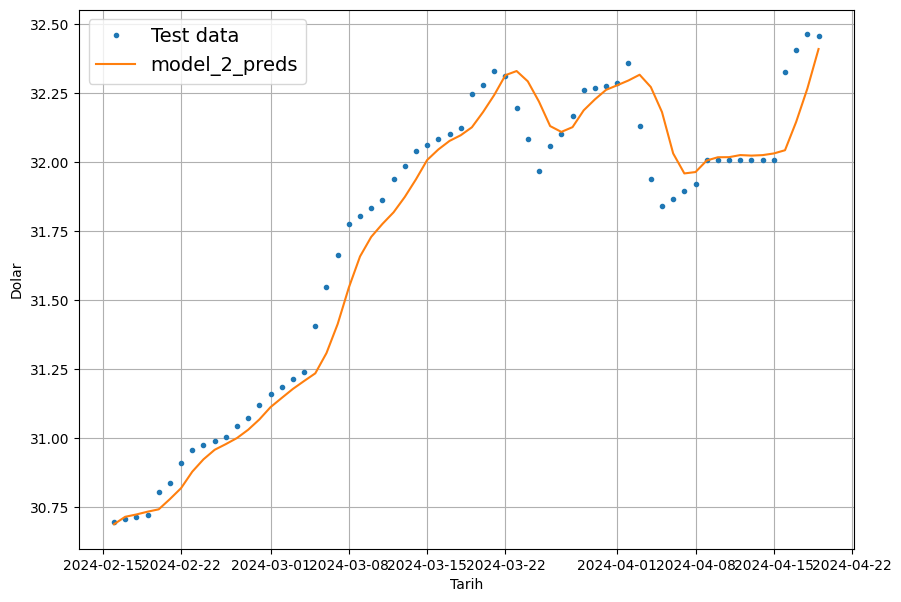

In [32]:
offset = 300
plt.figure(figsize=(10,7))
# Account for test_window offset when plotting
plot_time_series(timesteps=X_test[-len(test_windows):],values=test_labels[:,0],start=offset,label="Test data")
plot_time_series(timesteps=X_test[-len(test_windows):],values=model_2_preds,start=offset,format="-",label="model_2_preds")